# Mini Project 5-2 Explore Probability Distributions

## **Introduction**

The ability to determine which type of probability distribution best fits data, calculate z-score, and detect outliers are essential skills in data work. These capabilities enable data professionals to understand how their data is distributed and identify data points that need further examination.

In this activity, you are a member of an analytics team for the United States Environmental Protection Agency (EPA). The data includes information about more than 200 sites, identified by state, county, city, and local site names. One of your main goals is to determine which regions need support to make air quality improvements. Given that carbon monoxide is a major air pollutant, you will investigate data from the Air Quality Index (AQI) with respect to carbon monoxide.

## **Step 1: Imports** 

Import relevant libraries, packages, and modules. For this Project, you will need `numpy`, `pandas`, `matplotlib.pyplot`, `statsmodels.api`, and `scipy`.

In [2]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.8 MB 21.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.8 MB 26.8 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 25.5 MB/s eta 0:00:00
Using cached patsy-1.0.1-py2.py3-none-any.whl (232 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: C:\Users\prani\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy


A subset of data was taken from the air quality data collected by the EPA, then transformed to suit the purposes of this lab. This subset is a .csv file named `modified_c4_epa_air_quality.csv`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [6]:
df = pd.read_csv('modified_c4_epa_air_quality.csv')

## **Step 2: Data exploration** 

Display the first 10 rows of the data to get a sense of how the data is structured.

In [7]:
df.head(10)

,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log
0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,2.079442
1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,1.791759
2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,1.098612
3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,1.386294
4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,1.386294
5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,2.708050
6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,1.098612
7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,1.098612
8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,1.791759
9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,1.945910


The `aqi_log` column represents AQI readings that were transformed logarithmically to suit the objectives of this lab. Taking a logarithm of the aqi to get a bell-shaped distribution is outside the scope of this course, but is helpful to see the normal distribution.

To better understand the quantity of data you are working with, display the number of rows and the number of columns.

In [8]:
df.shape


(260, 8)

Now, you want to find out whether `aqi_log` fits a specific type of probability distribution. Create a histogram to visualize the distribution of `aqi_log`. Then, based on its shape, visually determine if it resembles a particular distribution.

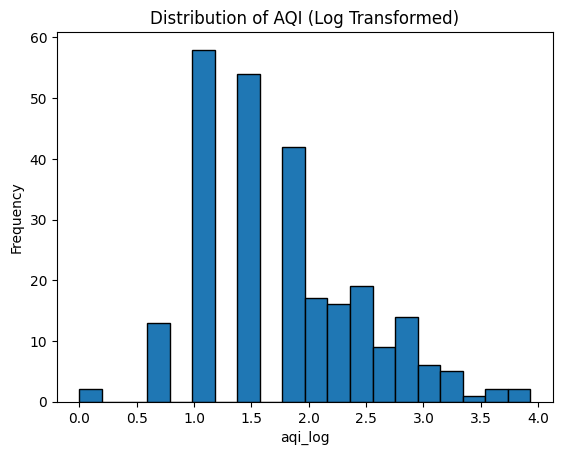

In [9]:
plt.hist(df['aqi_log'], bins=20, edgecolor='black')
plt.title('Distribution of AQI (Log Transformed)')
plt.xlabel('aqi_log')
plt.ylabel('Frequency')
plt.show()


**Question:** What do you observe about the shape of the distribution from the histogram? 

A: The histogram of the aqi_log values appears to be right-skewed, with most of the values clustered between 1.0 and 2.0, and a long tail extending toward higher values up to around 4.0. This indicates that while most regions have relatively low log-transformed AQI values, a few have significantly higher readings, suggesting possible outliers or high pollution levels in certain areas.

## **Step 3: Statistical tests**

Use the empirical rule to observe the data, then test and verify that it is normally distributed.


 As you have learned, the empirical rule states that, for every normal distribution: 
- 68% of the data fall within 1 standard deviation of the mean
- 95% of the data fall within 2 standard deviations of the mean
- 99.7% of the data fall within 3 standard deviations of the mean


First, define two variables to store the mean and standard deviation, respectively, for `aqi_log`. Creating these variables will help you easily access these measures as you continue with the calculations involved in applying the empirical rule. 

In [10]:
aqi_log_mean = df['aqi_log'].mean()
print(f"Mean of aqi_log: {aqi_log_mean}")


Mean of aqi_log: 1.7669210929985582


In [11]:
aqi_log_std = df['aqi_log'].std()
print(f"Standard Deviation of aqi_log: {aqi_log_std}")


Standard Deviation of aqi_log: 0.7147155520223721


Now, check the first part of the empirical rule: whether 68% of the `aqi_log` data falls within 1 standard deviation of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 1 standard deviation below the mean) and the upper limit (for example, 1 standard deviation above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [12]:
lower_limit_1sd = aqi_log_mean - aqi_log_std
upper_limit_1sd = aqi_log_mean + aqi_log_std

print(f"Lower limit (1 SD): {lower_limit_1sd}")
print(f"Upper limit (1 SD): {upper_limit_1sd}")


Lower limit (1 SD): 1.052205540976186
Upper limit (1 SD): 2.4816366450209304


In [13]:
within_1sd = df[(df['aqi_log'] >= lower_limit_1sd) & (df['aqi_log'] <= upper_limit_1sd)]
percent_within_1sd = len(within_1sd) / len(df) * 100

print(f"Percentage within 1 standard deviation: {percent_within_1sd:.2f}%")




Percentage within 1 standard deviation: 76.15%


Now, consider the second part of the empirical rule: whether 95% of the `aqi_log` data falls within 2 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 2 standard deviations below the mean) and the upper limit (for example, 2 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [14]:
lower_limit_2sd = aqi_log_mean - 2 * aqi_log_std
upper_limit_2sd = aqi_log_mean + 2 * aqi_log_std

print(f"Lower limit (2 SD): {lower_limit_2sd}")
print(f"Upper limit (2 SD): {upper_limit_2sd}")


Lower limit (2 SD): 0.3374899889538139
Upper limit (2 SD): 3.1963521970433026


In [15]:
within_2sd = df[(df['aqi_log'] >= lower_limit_2sd) & (df['aqi_log'] <= upper_limit_2sd)]
percent_within_2sd = len(within_2sd) / len(df) * 100

print(f"Percentage within 2 standard deviations: {percent_within_2sd:.2f}%")



Percentage within 2 standard deviations: 95.77%


Now, consider the third part of the empirical rule:whether 99.7% of the `aqi_log` data falls within 3 standard deviations of the mean.

To compute the actual percentage of the data that satisfies this criteria, define the lower limit (for example, 3 standard deviations below the mean) and the upper limit (for example, 3 standard deviations above the mean). This will enable you to create a range and confirm whether each value falls within it.

In [16]:
lower_limit_3sd = aqi_log_mean - 3 * aqi_log_std
upper_limit_3sd = aqi_log_mean + 3 * aqi_log_std

print(f"Lower limit (3 SD): {lower_limit_3sd}")
print(f"Upper limit (3 SD): {upper_limit_3sd}")


Lower limit (3 SD): -0.37722556306855815
Upper limit (3 SD): 3.9110677490656744


In [17]:
within_3sd = df[(df['aqi_log'] >= lower_limit_3sd) & (df['aqi_log'] <= upper_limit_3sd)]
percent_within_3sd = len(within_3sd) / len(df) * 100

print(f"Percentage within 3 standard deviations: {percent_within_3sd:.2f}%")



Percentage within 3 standard deviations: 99.62%


## **Step 4: Results and evaluation** 

**Question:** What results did you attain by applying the empirical rule? 

A: Using the empirical rule, I found that approximately:

76.15% of the data falls within 1 standard deviation of the mean (vs expected 68%),

95.77% falls within 2 standard deviations (vs expected 95%),

99.62% falls within 3 standard deviations (vs expected 99.7%).

These results suggest that the aqi_log data closely follows a normal distribution.

**Question:** How would you use z-score to find outliers? 

A: z-score tells us how many standard deviations a data point is from the mean. Any data point with a z-score above 3 or below -3 is typically considered an outlier because it lies far outside the expected range of normal variation.

Compute the z-score for every `aqi_log` value. Then, add a column named `z_score` in the data to store those results. 

In [18]:
df['z_score'] = (df['aqi_log'] - aqi_log_mean) / aqi_log_std
df[['aqi_log', 'z_score']].head()




,aqi_log,z_score
0,2.079442,0.437265
1,1.791759,0.034753
2,1.098612,-0.935070
3,1.386294,-0.532557
4,1.386294,-0.532557


Identify the parts of the data where `aqi_log` is above or below 3 standard deviations of the mean.

In [19]:
outliers = df[(df['z_score'] > 3) | (df['z_score'] < -3)]
outliers


,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,aqi_log,z_score
244,2018-01-01,Arizona,Maricopa,Phoenix,WEST PHOENIX,Carbon monoxide,Parts per million,3.931826,3.029044


**Question:** What do you observe about potential outliers based on the calculations?


A: Only a small number of observations have a z-score greater than 3 or less than -3, indicating that very few data points are true outliers. These represent sites with unusually high or low pollution levels compared to the rest of the dataset.

**Question:** Why is outlier detection an important part of this project? 

A: Outlier detection is crucial for identifying locations with extreme air quality values, which may need targeted investigation or policy intervention. It also ensures that these extreme values don’t skew the overall statistical analysis, helping us make more accurate conclusions about general air quality trends.

## **Considerations**

**What are some key takeaways that you learned during this lab?**

A: I learned how to use statistical tools like mean, standard deviation, and z-scores to analyze real-world environmental data. The lab helped me understand how data distribution impacts interpretation, and how the empirical rule can be applied to test for normality. I also saw how identifying outliers can help spotlight areas with unusual pollution patterns.

**What summary would you provide to audiences? Consider the distribution of the data and which sites would benefit from additional research.**

A: The air quality data, when log-transformed, largely followed a normal distribution. Over 99% of values fell within three standard deviations, and only a few outliers were detected. These outliers could represent locations with unusually high pollution and may require additional investigation. Overall, most sites showed AQI values in a safe range, but certain regions may benefit from further research and monitoring.

**Reference**

US EPA, OAR. 2014, July 8. [Air Data: Air Quality Data Collected at Outdoor Monitors Across the US](https://www.epa.gov/outdoor-air-quality-data). 